In [3]:
import numpy as np
import sys
import os

# Get the parent directory and add it to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

# Now import the class
from multi_dim_env import MultivariatePolyEnv

In [1]:
def shift_polynomial(self):
        """
        Randomize the polynomial parameters to create a new function.
        'a' should remain negative to ensure a mountain shape.
        """
        self.a = np.random.uniform(-2.0, -0.5)  # Keep a negative for a mountain shape
        self.b = np.random.uniform(-5.0, 5.0)   # Random slope
        self.c = np.random.uniform(5.0, 20.0)   # Random height
        
        # Compute the new peak position
        self.x_max = -self.b / (2 * self.a)

        # Ensure the peak is within the valid range
        self.x_max = np.clip(self.x_max, self.x_range[0], self.x_range[1])
        
def compute_y(self, x):
        """
        Compute the polynomial value at x: f(x) = a*x^2 + b*x + c.
        """
        return self.a * x**2 + self.b * x + self.c

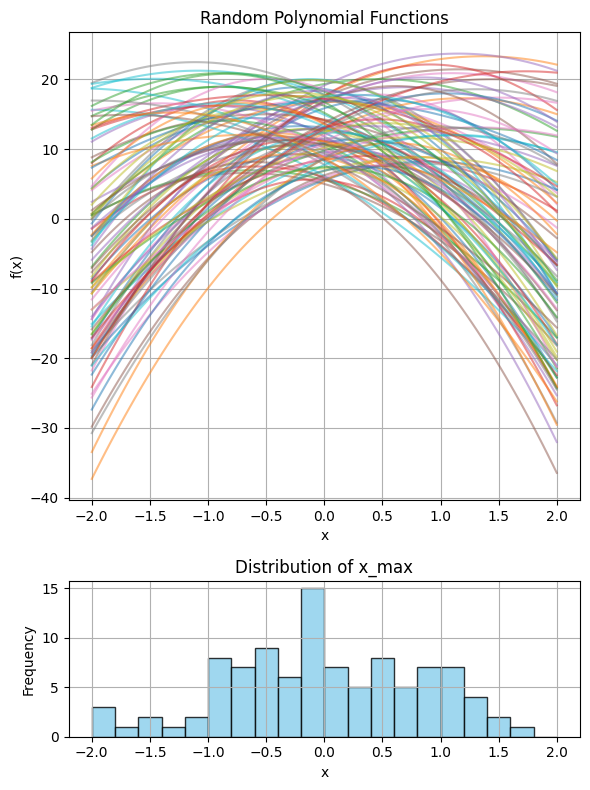

In [4]:
import matplotlib.pyplot as plt

# Assuming the class and methods are defined in the previous cells
class Polynomial:
    def __init__(self, x_range):
        self.x_range = x_range
        self.shift_polynomial()

    def shift_polynomial(self):
        """
        Randomize the polynomial parameters to create a new function.
        'a' should remain negative to ensure a mountain shape.
        """
        self.a = np.random.uniform(-2.0, -7.0)  # Keep a negative for a mountain shape
        self.b = np.random.uniform(-10.0, 10.0)   # Random slope
        self.c = np.random.uniform(5.0, 20.0)   # Random height
        
        # Compute the new peak position
        self.x_max = -self.b / (2 * self.a)

        # Ensure the peak is within the valid range
        self.x_max = np.clip(self.x_max, self.x_range[0], self.x_range[1])
        

    def compute_y(self, x):
        """
        Compute the polynomial value at x: f(x) = a*x^2 + b*x + c.
        """
        return self.a * x**2 + self.b * x + self.c

# Generate x values
x_values = np.linspace(-2, 2, 100)

# Create a figure with two subplots (polynomials and histogram)
fig, ax = plt.subplots(2, 1, figsize=(6, 8), gridspec_kw={'height_ratios': [3, 1]})

# List to store x_max values
max_x_values = []

# Generate and plot 100 functions
for _ in range(100):
    poly = Polynomial(x_range=(-2, 2))
    y_values = poly.compute_y(x_values)
    max_x_values.append(poly.x_max)  # Store max_x values
    ax[0].plot(x_values, y_values, alpha=0.5)

# Configure main plot
ax[0].set_title('Random Polynomial Functions')
ax[0].set_xlabel('x')
ax[0].set_ylabel('f(x)')
ax[0].grid(True)

# Plot histogram of max_x values
ax[1].hist(max_x_values, bins=20, range=(-2, 2), color='skyblue', edgecolor='black', alpha=0.8)
ax[1].set_title('Distribution of x_max')
ax[1].set_xlabel('x')
ax[1].set_ylabel('Frequency')
ax[1].grid(True)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # required for 3D plotting

# Assuming the MultivariatePolyEnv code from before is available in the namespace.
# For demonstration, we instantiate the environment with action_dim=2.
class MultivariatePolyEnv:
    def __init__(self, env_config=None, degree=2, action_dim=2, x_range=(-10, 10), max_episode_steps=12):
        self.degree = degree
        self.action_dim = action_dim
        self.x_range = x_range  # same range for each dimension
        self.max_episode_steps = max_episode_steps
        # Initialize polynomial parameters (will be randomized on reset/shift)
        self.x_max = None
        self.c = None
        self.weights = None
        self.shift_polynomial()
    
    def shift_polynomial(self):
        # Randomize the maximum location uniformly for each dimension.
        self.x_max = np.random.uniform(self.x_range[0], self.x_range[1], size=(self.action_dim,))
        # Randomize the constant such that f(x_max) = c, and weights.
        self.c = np.random.uniform(5.0, 20.0)
        self.weights = np.random.uniform(0.5, 2.0, size=(self.action_dim,))
    
    # def compute_y(self, x):
    #     """
    #     Compute the polynomial value:
    #         f(x) = c - sum_{i=1}^{action_dim} (w_i * (x_i - x_max_i)**degree)
    #     """
    #     diff = x - self.x_max
    #     return self.c - np.sum(self.weights * (diff ** self.degree))
    
    def compute_y(self, x):
        """
        Compute the polynomial value for a batch of inputs:
            f(x) = c - sum_{i=1}^{action_dim} (w_i * (x_i - x_max_i)**degree)
            
        Supports inputs of shape `(batch_size, action_dim)`.
        If `x` is `(action_dim,)`, it is treated as `(1, action_dim)`.
        """
        x = np.atleast_2d(x)  # Ensure x is (batch_size, action_dim)
        
        # Compute difference
        diff = x - self.x_max  # Shape: (batch_size, action_dim)
        
        # Compute weighted polynomial term
        weighted_term = self.weights * (diff ** self.degree)  # Shape: (batch_size, action_dim)
        
        # Sum across action_dim to get final output
        result = self.c - np.sum(weighted_term, axis=1)  # Shape: (batch_size,)
        
        return result.squeeze()  # Convert (1,) to scalar if needed
    

# Create an instance of the environment.
env = MultivariatePolyEnv(degree=2, action_dim=2, x_range=(-10, 10))

env.shift_polynomial()
print("Randomized polynomial parameters:")
print("  x_max =", env.x_max)
print("  c =", env.c)
print("  weights =", env.weights)

f_at_xmax = env.compute_y(env.x_max)
print("  f(x_max) =", f_at_xmax)

# Build a grid, compute Z, and find the max:
x0 = np.linspace(env.x_range[0], env.x_range[1], 50)
x1 = np.linspace(env.x_range[0], env.x_range[1], 50)
X0, X1 = np.meshgrid(x0, x1)

Z = env.c - (env.weights[0] * ((X0 - env.x_max[0]) ** env.degree)
           + env.weights[1] * ((X1 - env.x_max[1]) ** env.degree))

Z_max = np.max(Z)
max_idx = np.unravel_index(np.argmax(Z), Z.shape)
max_loc = (X0[max_idx], X1[max_idx])

print("  Max of Z =", Z_max)
print("  Max location in grid =", max_loc)

# Create a grid over the 2D input space.
grid_points = 100
x0 = np.linspace(env.x_range[0], env.x_range[1], grid_points)
x1 = np.linspace(env.x_range[0], env.x_range[1], grid_points)
X0, X1 = np.meshgrid(x0, x1)

# print(f'X0 shape: {X0.shape}, X1 shape: {X1.shape}', X0)

# Compute function values on the grid.
# Since our function is separable, we can compute:
# f(x) = c - (w0*(x0 - x_max[0])**degree + w1*(x1 - x_max[1])**degree)
Z = env.c - (env.weights[0] * ((X0 - env.x_max[0]) ** env.degree) +
             env.weights[1] * ((X1 - env.x_max[1]) ** env.degree))

# Prepare the figure.
fig = plt.figure(figsize=(14, 6))

# --- 3D Surface Plot ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X0, X1, Z, cmap='viridis', edgecolor='none', alpha=0.8)
ax1.set_title('3D Surface Plot of Multivariate Polynomial')
ax1.set_xlabel('x[0]')
ax1.set_ylabel('x[1]')
ax1.set_zlabel('f(x)')
# Mark the maximum location: f(x_max)=c.
ax1.scatter(env.x_max[0], env.x_max[1], env.c, color='r', s=50, label='Maximum')
ax1.legend()
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# --- 2D Contour Plot ---
ax2 = fig.add_subplot(1, 2, 2)
cont = ax2.contourf(X0, X1, Z, levels=50, cmap='viridis')
ax2.set_title('2D Contour Plot of Multivariate Polynomial')
ax2.set_xlabel('x[0]')
ax2.set_ylabel('x[1]')
# Mark the maximum location on the contour plot.
ax2.scatter(env.x_max[0], env.x_max[1], color='r', s=50, label='Maximum')
ax2.legend()
fig.colorbar(cont, ax=ax2)

plt.tight_layout()
plt.show()


Randomized polynomial parameters:
  x_max = [3.90799456]
  c = 9.365430135712959
  weights = [1.05207098]
  f(x_max) = 9.365430135712959


IndexError: index 1 is out of bounds for axis 0 with size 1

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def visualize_multivariate_polynomial(env, num_functions=100):
    """
    Visualize multiple random functions from the multivariate polynomial environment.
    
    Args:
        env: MultivariatePolynomialEnv instance
        num_functions: Number of random functions to generate
    """
    if env.num_dimensions == 2:
        visualize_2d(env, num_functions)
    else:
        visualize_nd(env, num_functions)

def visualize_2d(env, num_functions):
    """Visualize 2D polynomial functions using contour plots."""
    # Create grid of points
    x = np.linspace(env.x_range[0], env.x_range[1], 100)
    y = np.linspace(env.x_range[0], env.x_range[1], 100)
    X, Y = np.meshgrid(x, y)
    
    # Create figure with subplots
    fig = plt.figure(figsize=(15, 5))
    
    # Plot one random function as contour
    ax1 = fig.add_subplot(131)
    env.shift_polynomial()
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            point = np.array([X[i,j], Y[i,j]])
            Z[i,j] = env.compute_y(point)
    
    contour = ax1.contourf(X, Y, Z, levels=20, cmap='viridis')
    ax1.plot(env.x_max[0], env.x_max[1], 'r*', markersize=10, label='Maximum')
    ax1.set_title('Sample Function Contour')
    ax1.set_xlabel('x₁')
    ax1.set_ylabel('x₂')
    fig.colorbar(contour, ax=ax1)
    ax1.legend()
    
    # Plot one random function as 3D surface
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
    ax2.set_title('Sample Function Surface')
    ax2.set_xlabel('x₁')
    ax2.set_ylabel('x₂')
    ax2.set_zlabel('f(x₁,x₂)')
    
    # Plot distribution of maxima
    ax3 = fig.add_subplot(133)
    max_points = []
    for _ in range(num_functions):
        env.shift_polynomial()
        max_points.append(env.x_max)
    max_points = np.array(max_points)
    
    ax3.scatter(max_points[:,0], max_points[:,1], alpha=0.5)
    ax3.set_title('Distribution of Maxima')
    ax3.set_xlabel('x₁')
    ax3.set_ylabel('x₂')
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()

def visualize_nd(env, num_functions):
    """Visualize higher-dimensional polynomial functions using 1D slices."""
    # Create figure with subplots
    fig, axes = plt.subplots(1, env.num_dimensions, figsize=(5*env.num_dimensions, 4))
    if env.num_dimensions == 1:
        axes = [axes]
    
    # Generate base point at maximum
    env.shift_polynomial()
    base_point = env.x_max.copy()
    x = np.linspace(env.x_range[0], env.x_range[1], 100)
    
    # Plot 1D slices through maximum for each dimension
    for dim in range(env.num_dimensions):
        ax = axes[dim]
        
        # Create and plot multiple functions
        for _ in range(num_functions):
            env.shift_polynomial()
            base_point = env.x_max.copy()
            y_values = []
            
            for x_val in x:
                point = base_point.copy()
                point[dim] = x_val
                y_values.append(env.compute_y(point))
            
            ax.plot(x, y_values, alpha=0.3)
            ax.plot(env.x_max[dim], env.compute_y(env.x_max), 'r*', markersize=5)
        
        ax.set_title(f'Dimension {dim+1} Slice')
        ax.set_xlabel(f'x_{dim+1}')
        ax.set_ylabel('f(x)')
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()
    
env = MultivariatePolynomialEnv(num_dimensions=2, x_range=(-2, 2))
visualize_multivariate_polynomial(env, num_functions=1)


NameError: name 'MultivariatePolynomialEnv' is not defined

(100,)


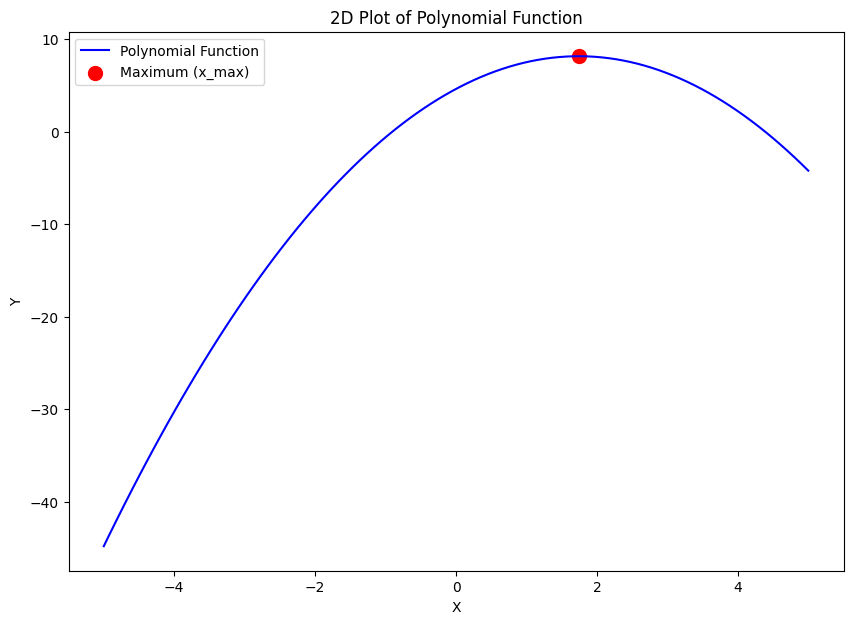

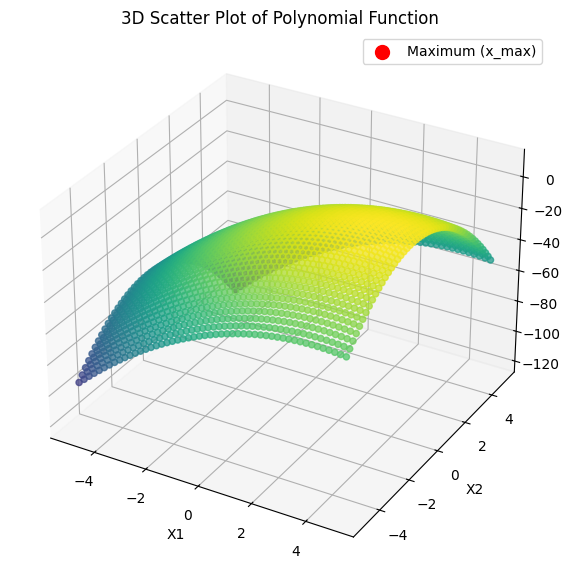

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class PolynomialFunction:
    def __init__(self, action_dim, degree, x_range):
        self.action_dim = action_dim
        self.degree = degree
        self.x_range = x_range
        self.shift_polynomial()

    def shift_polynomial(self):
        # Randomize the maximum location uniformly for each dimension.
        self.x_max = np.random.uniform(self.x_range[0], self.x_range[1], size=(1, self.action_dim))
        # Randomize the constant such that f(x_max) = c, and weights.
        self.c = np.random.uniform(5.0, 20.0)
        self.weights = np.random.uniform(0.5, 2.0, size=(self.action_dim,))

    def compute_y(self, x):
        """
        Compute the polynomial value for a batch of inputs:
            f(x) = c - sum_{i=1}^{action_dim} (w_i * (x_i - x_max_i)**degree)
        """
        x = np.atleast_2d(x)  # Ensure x is (batch_size, action_dim)
        diff = x - self.x_max  # Compute difference
        weighted_term = self.weights * (diff ** self.degree)  # Apply weights
        result = self.c - np.sum(weighted_term, axis=1)  # Sum across dimensions
        return result.squeeze()  # Convert (1,) to scalar if needed

    def plot_3d(self, num_points=50):
        """
        Generate a 3D scatter plot for action_dim=2.
        """
        if self.action_dim != 2:
            raise ValueError("3D plotting is only supported for action_dim=2")

        # Generate a grid of points
        x1_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        x2_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        X1, X2 = np.meshgrid(x1_vals, x2_vals)
        X_grid = np.column_stack([X1.ravel(), X2.ravel()])  # Flatten to (num_points**2, 2)

        # Compute function values
        Y = self.compute_y(X_grid)

        # Plot
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')

        # Scatter plot
        ax.scatter(X_grid[:, 0], X_grid[:, 1], Y, c=Y, cmap='viridis', alpha=0.75)
        print(np.max(Y))
        # Mark the maximum
        print(self.x_max, self.c)
        ax.scatter(self.x_max[0,0], self.x_max[0,1], self.c, color='red', s=100, label="Maximum (x_max)")

        # Labels
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")
        ax.set_zlabel("Y")
        ax.set_title("3D Scatter Plot of Polynomial Function")

        plt.legend()
        plt.show()
        
    def plot_2d(self, num_points=100):
        """
        Generate a 2D plot for action_dim=1.
        """
        if self.action_dim != 1:
            raise ValueError("2D plotting is only supported for action_dim=1")
            
        # Generate a range of x values and compute corresponding y values.
        x_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        y_vals = []
        for i in range(len(x_vals)):
            y = self.compute_y(x_vals[i])
            y_vals.append(y)
        # y_vals = self.compute_y(x_vals)
        y_vals = np.array(y_vals)
        
        print(y_vals.shape)
        
        # Create the plot.
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.plot(x_vals, y_vals, label="Polynomial Function", color='blue')
        
        # Mark the maximum point.
        ax.scatter(self.x_max[0, 0], self.c, color='red', s=100, label="Maximum (x_max)")
        
        # Set labels and title.
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_title("2D Plot of Polynomial Function")
        ax.legend()
        plt.show()

    def plot_3d(self, num_points=50):
        """
        Generate a 3D scatter plot for action_dim=2.
        """
        if self.action_dim != 2:
            raise ValueError("3D plotting is only supported for action_dim=2")

        # Generate a grid of points
        x1_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        x2_vals = np.linspace(self.x_range[0], self.x_range[1], num_points)
        X1, X2 = np.meshgrid(x1_vals, x2_vals)
        X_grid = np.column_stack([X1.ravel(), X2.ravel()])  # Flatten to (num_points**2, 2)

        # Compute function values
        Y = self.compute_y(X_grid)

        # Plot
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(X_grid[:, 0], X_grid[:, 1], Y, c=Y, cmap='viridis', alpha=0.75)

        # Mark the maximum
        ax.scatter(self.x_max[0,0], self.x_max[0,1], self.c, color='red', s=100, label="Maximum (x_max)")

        # Labels
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")
        ax.set_zlabel("Y")
        ax.set_title("3D Scatter Plot of Polynomial Function")
        plt.legend()
        plt.show()

# Example Usage for 2D Plotting (action_dim=1)
poly_fn = PolynomialFunction(action_dim=1, degree=2, x_range=(-5, 5))
poly_fn.plot_2d()

# Example Usage
poly_fn = PolynomialFunction(action_dim=2, degree=2, x_range=(-5, 5))
poly_fn.plot_3d()
